### **ShowTime**

> An OTT service provider and offers a wide variety of content (movies, web shows, etc.) for its users. They want to determine the driver variables for first-day content viewership so that they can take necessary measures to improve the viewership of the content on their platform. Some of the reasons for the decline in viewership of content would be the decline in the number of people coming to the platform, decreased marketing spend, content timing clashes, weekends and holidays, etc. They have hired you as a Data Scientist, shared the data of the current content on their platform, and asked you to analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.

In [1]:
import numpy as np
import pandas as pd
import pylab
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("/content/drive/MyDrive/PGP_DSA/Projects/Predictive Modeling with Linear Regression/ottdata.csv")
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [3]:
df.shape

(1000, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
major_sports_event,1000.0,0.40000,0.490143,0.00,0.0000,0.00,1.000,1.00
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.nunique()

,0
visitors,56
ad_impressions,80
major_sports_event,2
genre,8
dayofweek,7
season,4
views_trailer,799
views_content,61


In [8]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0




---



> ## Univariate Analysis

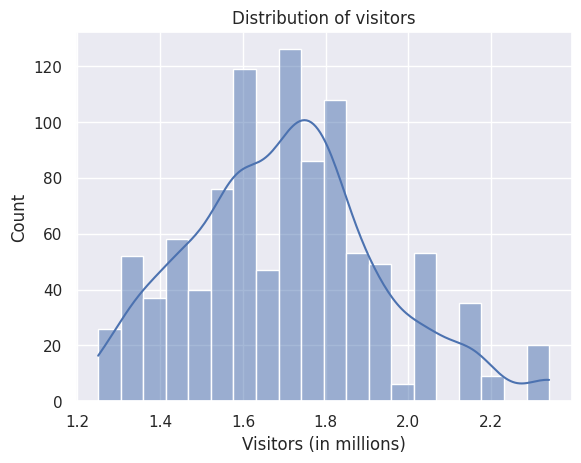

In [9]:
sns.histplot(data = df, x = 'visitors', kde = True)
plt.title('Distribution of visitors')
plt.xlabel('Visitors (in millions)');

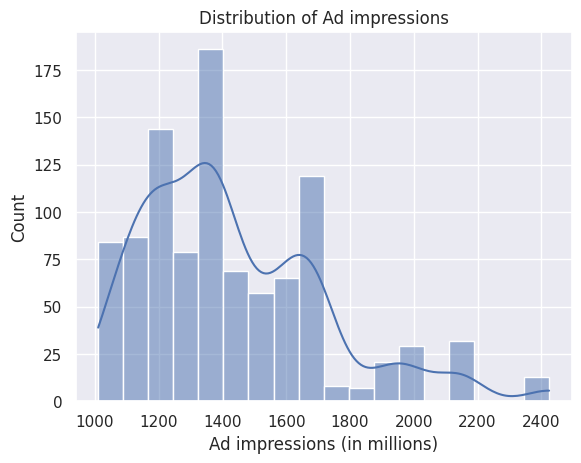

In [10]:
sns.histplot(data = df, x = 'ad_impressions', kde = True)
plt.title('Distribution of Ad impressions')
plt.xlabel('Ad impressions (in millions)');

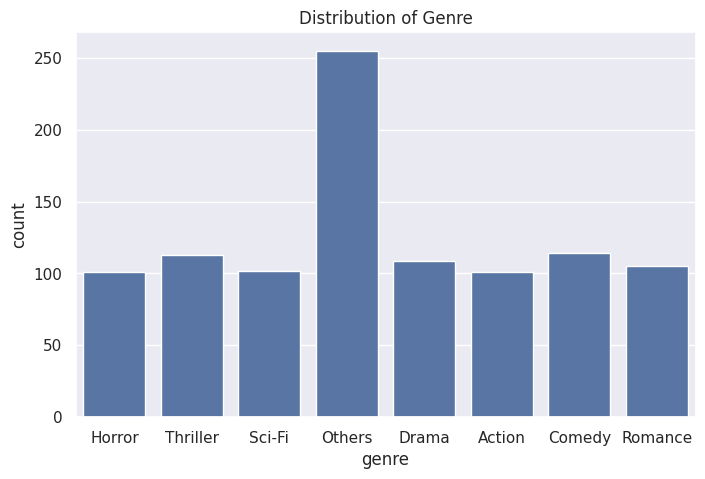

In [11]:
plt.figure(figsize = (8,5))
sns.countplot(data = df, x = 'genre')
plt.title('Distribution of Genre');

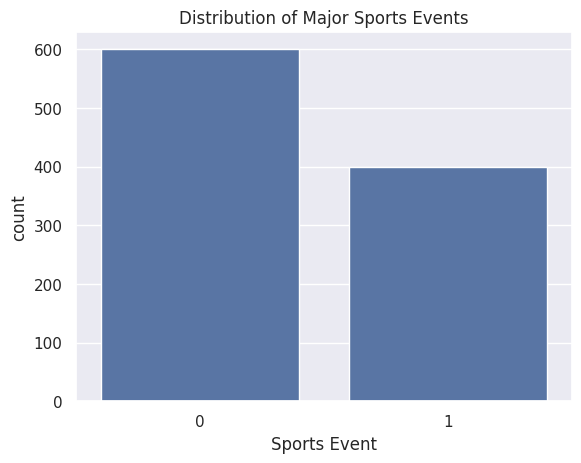

In [12]:
sns.countplot(data = df, x = 'major_sports_event')
plt.title('Distribution of Major Sports Events')
plt.xlabel('Sports Event');

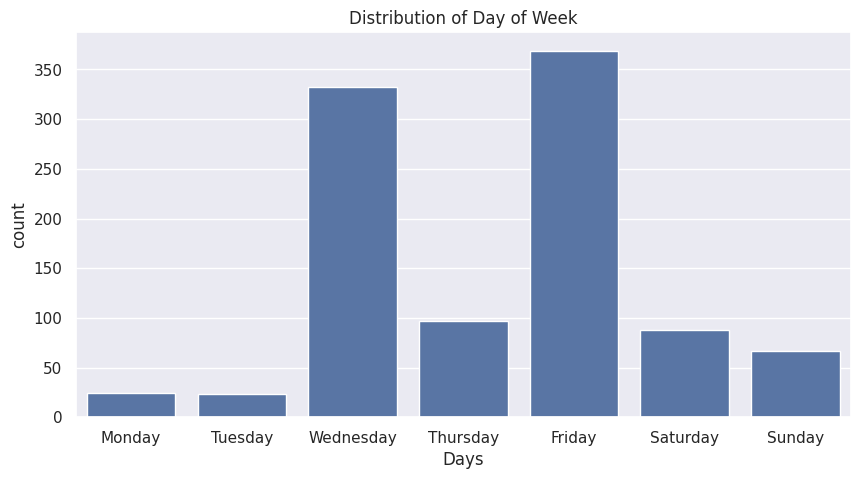

In [13]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'dayofweek', order = weekday_order)
plt.title('Distribution of Day of Week')
plt.xlabel('Days');

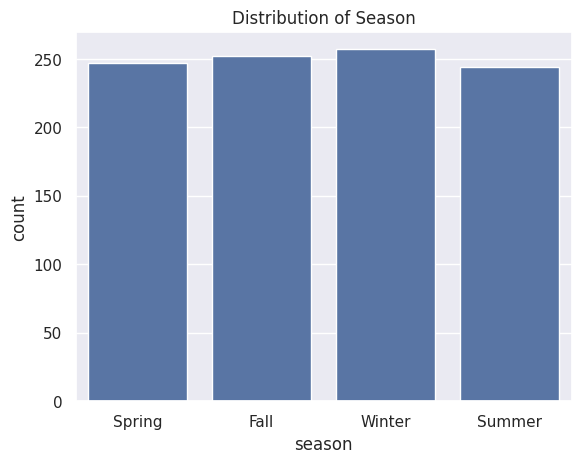

In [14]:
sns.countplot(data = df, x = 'season')
plt.title('Distribution of Season');

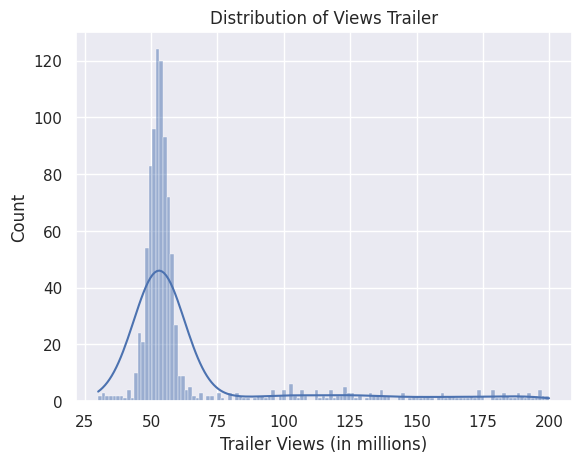

In [15]:
sns.histplot(data = df, x = 'views_trailer', kde = True)
plt.title('Distribution of Views Trailer')
plt.xlabel('Trailer Views (in millions)');

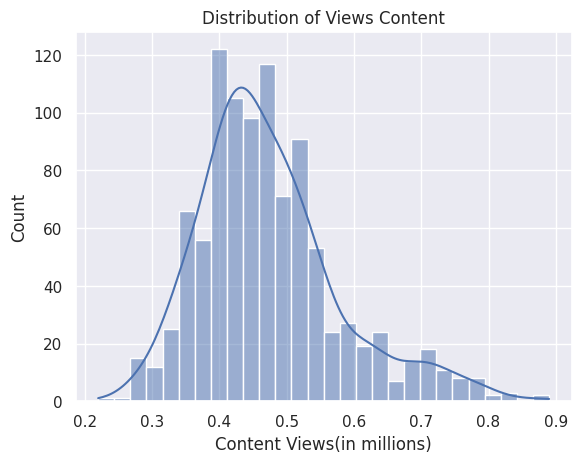

In [16]:
sns.histplot(data = df, x = 'views_content', kde = True)
plt.title('Distribution of Views Content')
plt.xlabel('Content Views(in millions)');

> ## Bivariate Analysis

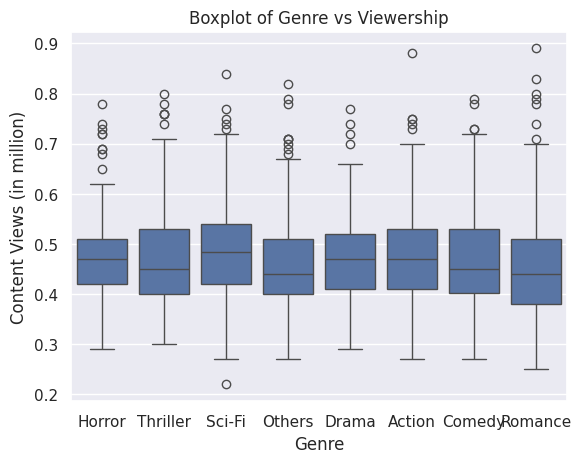

In [17]:
sns.boxplot(data = df, x = 'genre', y = 'views_content')
plt.title('Boxplot of Genre vs Viewership')
plt.xlabel('Genre')
plt.ylabel('Content Views (in million)');

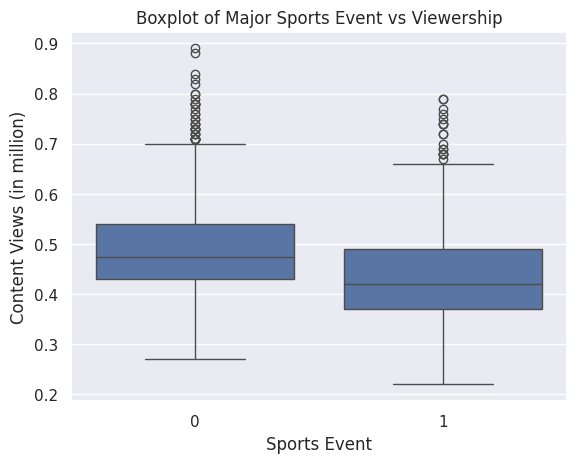

In [18]:
sns.boxplot(data = df, x = 'major_sports_event', y = 'views_content')
plt.title('Boxplot of Major Sports Event vs Viewership')
plt.xlabel('Sports Event')
plt.ylabel('Content Views (in million)');

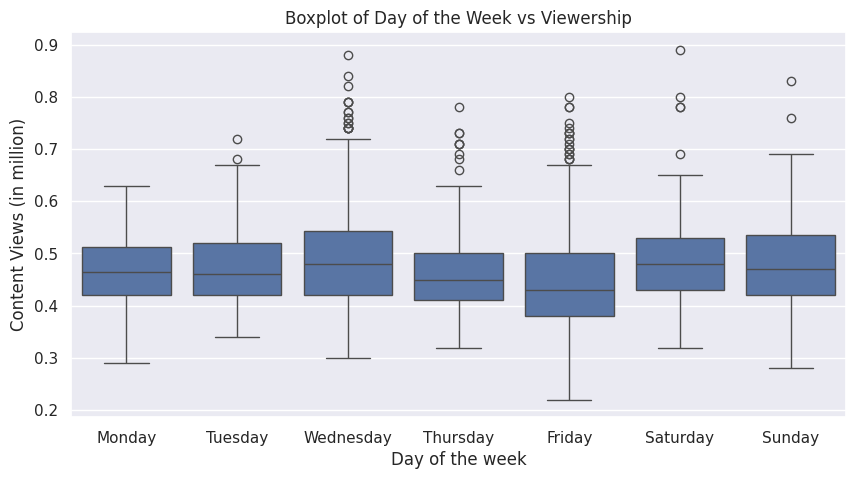

In [19]:
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = 'dayofweek', y = 'views_content', order = weekday_order)
plt.title('Boxplot of Day of the Week vs Viewership')
plt.xlabel('Day of the week')
plt.ylabel('Content Views (in million)');

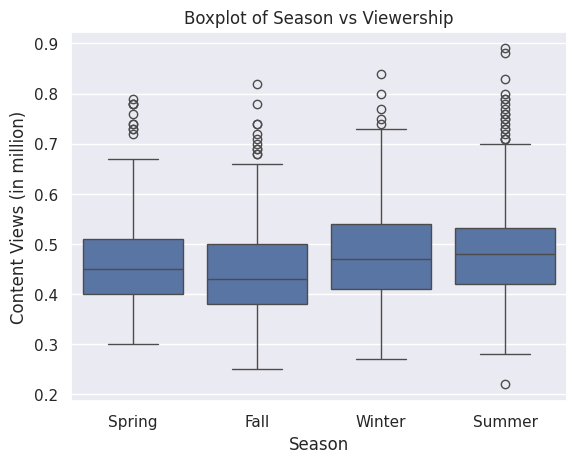

In [20]:
sns.boxplot(data = df, x = 'season', y = 'views_content')
plt.title('Boxplot of Season vs Viewership')
plt.xlabel('Season')
plt.ylabel('Content Views (in million)');

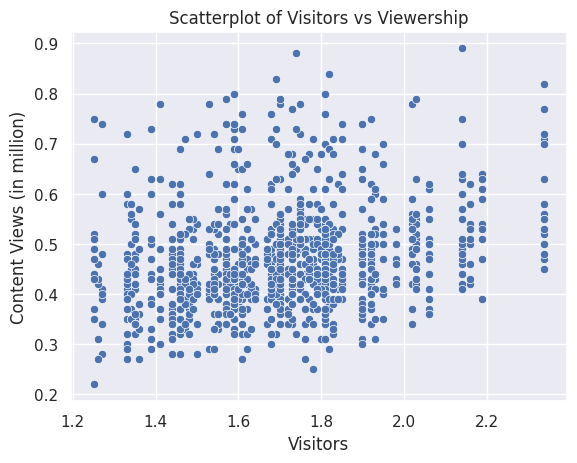

In [21]:
sns.scatterplot(data = df, y = 'views_content', x = 'visitors')
plt.title('Scatterplot of Visitors vs Viewership')
plt.xlabel('Visitors')
plt.ylabel('Content Views (in million)');

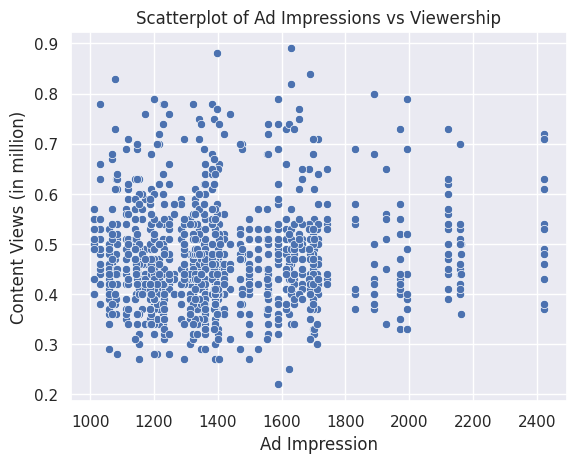

In [22]:
sns.scatterplot(data = df, x = 'ad_impressions', y = 'views_content')
plt.title('Scatterplot of Ad Impressions vs Viewership')
plt.xlabel('Ad Impression')
plt.ylabel('Content Views (in million)');

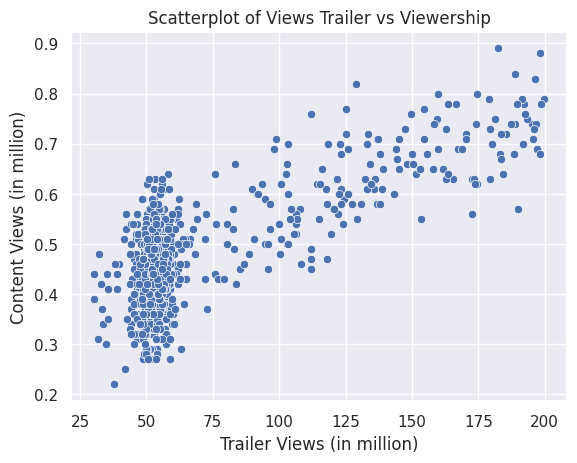

In [23]:
sns.scatterplot(data = df, x = 'views_trailer', y = 'views_content')
plt.title('Scatterplot of Views Trailer vs Viewership')
plt.xlabel('Trailer Views (in million)')
plt.ylabel('Content Views (in million)');



---



## Key Questions:

> ### 1. What does the distribution of content views look like?

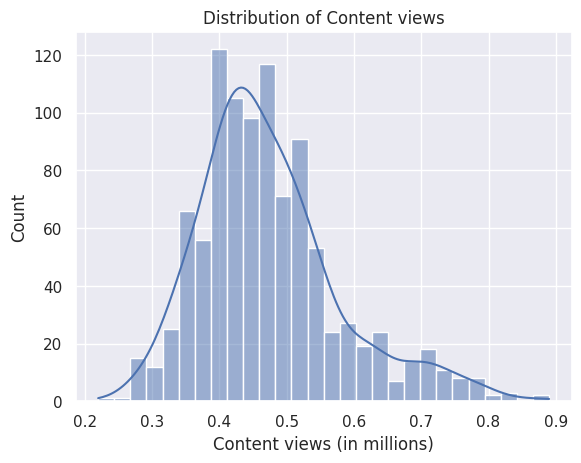

In [24]:
sns.histplot(data = df, x = 'views_content', kde = True)
plt.title('Distribution of Content views')
plt.xlabel('Content views (in millions)');

- The distribution is positively (right) skewed by a smaller number of high performing posts.
- Most content receives 0.4 - 0.5 million views(400,000 to 500,000 views).
- The right tail of the distribution which tends to 0.9 million (900,000), also indicates that a relatively smaller number of content achieves high view counts.

> ### 2. What does the distribution of genre look like?

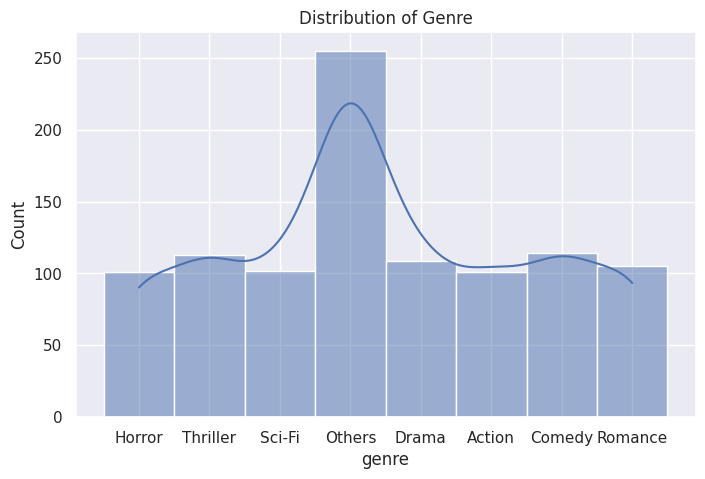

In [25]:
plt.figure(figsize = (8,5))
sns.histplot(data = df, x = 'genre', kde = True,)
plt.title('Distribution of Genre');

- The distribution of genre is balanced across the individual categories, while most of the categories have ~100-115 content items.
- The "Others" category is however significantly large, with over 250 items, making it the most represented category.

> ### 3. The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?




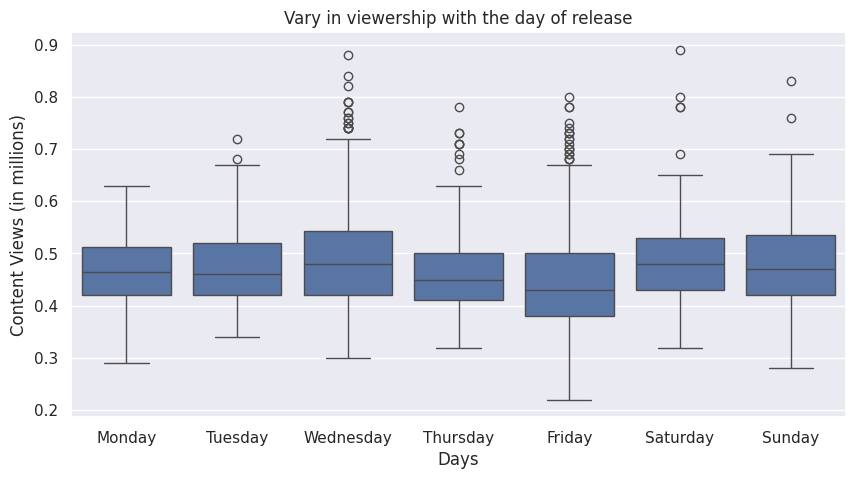

In [26]:
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = 'dayofweek', y = 'views_content', order = weekday_order)
plt.title('Vary in viewership with the day of release')
plt.xlabel('Days')
plt.ylabel('Content Views (in millions)');

- Viewership varies across release days, with Wednesday and Saturday showing the highest median content views, while Friday has the lowest median.

> ### 4. How does the viewership vary with the season of release?

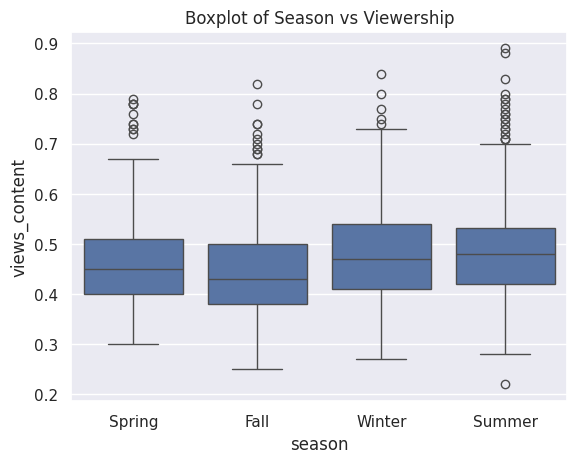

In [45]:
sns.boxplot(data = df, x = 'season', y = 'views_content')
plt.title('Boxplot of Season vs Viewership');

- Viewership varies across seasons, with Summer and Winter showing higher median content views compared with Spring and Fall.
- Fall has the lowest median viewership.
- The presence of variability and high-view outliers across all seasons indicates that season alone does not determine content performance.

> ### 5. What is the correlation between trailer views and content views?

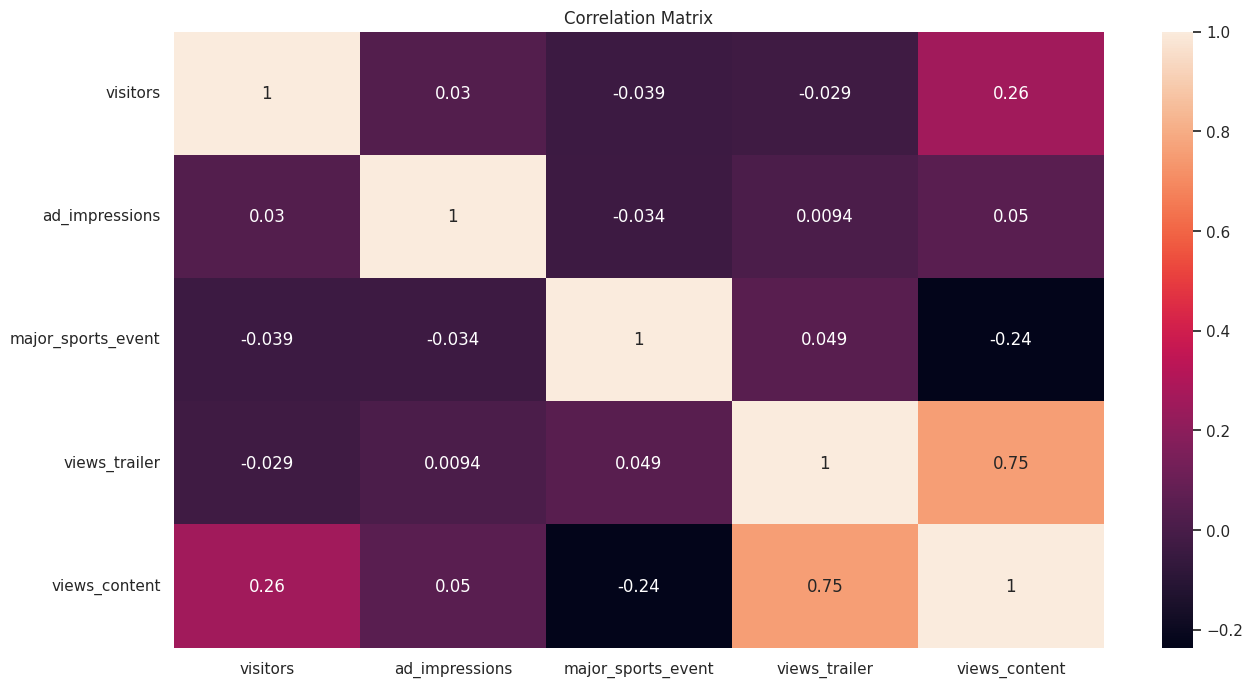

In [28]:
corr = df.corr(numeric_only = True)

plt.figure(figsize = (15,8))
sns.heatmap(corr, annot = True)
plt.title('Correlation Matrix');

- From the above heatmap, we can conclude that the correlation of trailer views and content views is 0.75.

> ### Outlier Detection

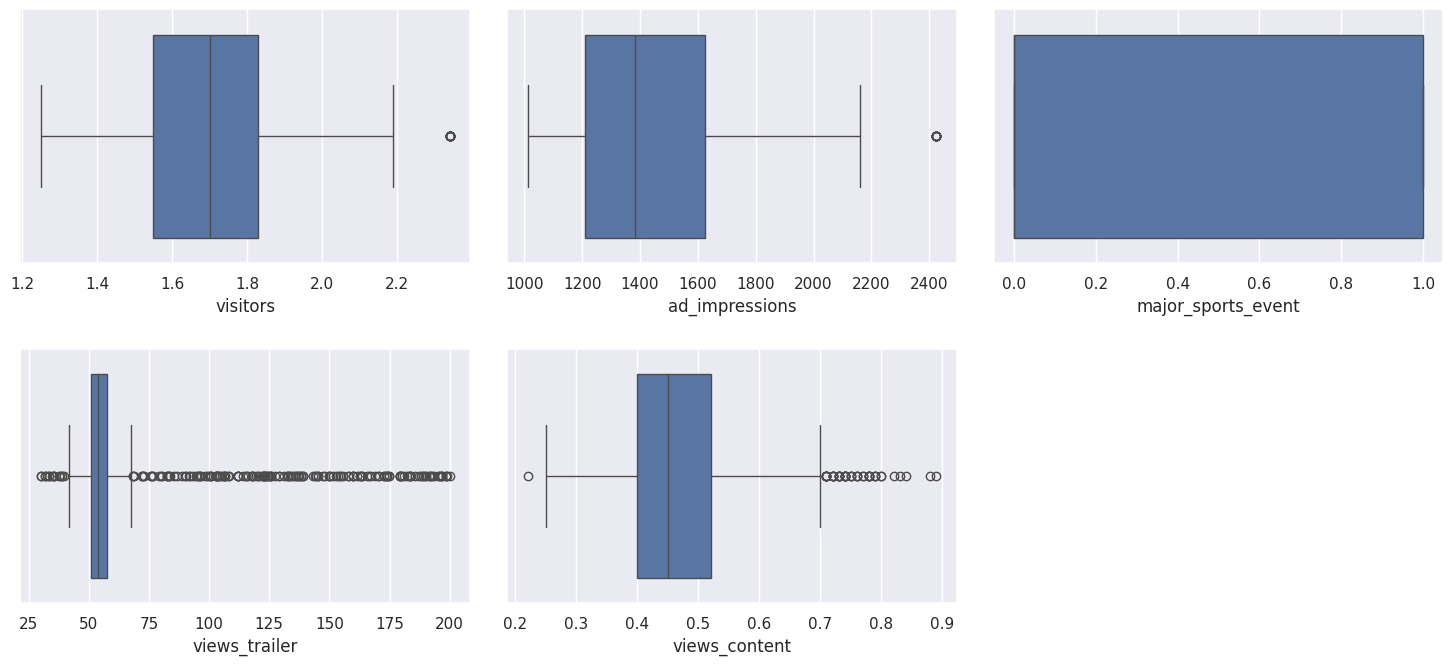

In [29]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, x=variable)
    plt.tight_layout(pad=2)

plt.show()

> ### Data Preparation for Modeling

In [30]:
X = df.drop('views_content', axis = 1)
y = df['views_content']

print(X.head())
print('----')
print(y.head())

   visitors  ad_impressions  major_sports_event     genre  dayofweek  season  \
0      1.67         1113.81                   0    Horror  Wednesday  Spring   
1      1.46         1498.41                   1  Thriller     Friday    Fall   
2      1.47         1079.19                   1  Thriller  Wednesday    Fall   
3      1.85         1342.77                   1    Sci-Fi     Friday    Fall   
4      1.46         1498.41                   0    Sci-Fi     Sunday  Winter   

   views_trailer  
0          56.70  
1          52.69  
2          48.74  
3          49.81  
4          55.83  
----
0    0.51
1    0.32
2    0.39
3    0.44
4    0.46
Name: views_content, dtype: float64


In [31]:
X = sm.add_constant(X)

In [32]:
X = pd.get_dummies(X, columns=['genre', 'dayofweek', 'season'], drop_first=True)
X.head()

,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,0,56.70,False,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
1,1.0,1.46,1498.41,1,52.69,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,1.0,1.47,1079.19,1,48.74,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,1.0,1.85,1342.77,1,49.81,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,1.46,1498.41,0,55.83,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [33]:
X = X.astype(float)
X.head()

,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,0.0,56.70,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,1.46,1498.41,1.0,52.69,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.47,1079.19,1.0,48.74,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.85,1342.77,1.0,49.81,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.46,1498.41,0.0,55.83,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [35]:
olsmod = sm.OLS(y_train, X_train).fit()
print(olsmod.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.32e-215
Time:                        11:27:02   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0602    

- Adjusted. R-squared:

Adjusted R-squared values generally range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
In our case, the value for adj. R-squared is 0.785.

- *const* coefficient: It is the Y-intercept.

It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the const coefficient.
In our case, the value for const coefficient is 0.0602.

> ### Model Performance Checks

In [36]:
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


def model_performance_regression(model, predictors, target):
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)
    adjr2 = adj_r2_score(predictors, target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    mape = mape_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [37]:
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmod, X_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.04853,0.038197,0.791616,0.785162,8.55644


In [38]:
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmod, X_test, y_test)
olsmodel_train_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.050603,0.040782,0.766447,0.748804,9.030464


> ### Checking for Linear Regression Assumptions

>> Test for Multicollinearity

In [39]:
def checking_vif(predictors):
    vif = pd.DataFrame()

    vif["feature"] = predictors.columns
    vif["VIF"] = [variance_inflation_factor(predictors.values, i) for i in range(len(predictors.columns))]

    return vif

In [40]:
checking_vif(X_train)

,feature,VIF
0,const,1.000000
1,visitors,1.027837
2,ad_impressions,1.029390
3,major_sports_event,1.065689
4,views_trailer,1.023551
5,genre_Comedy,1.917635
6,genre_Drama,1.926699
7,genre_Horror,1.904460
8,genre_Others,2.573779
9,genre_Romance,1.753525


In [41]:
olsmod = sm.OLS(y_train, X_train).fit()
print(olsmod.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.32e-215
Time:                        11:27:21   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0602    

- Sine the VIF's are below 5, we consider them as no significant multicollinearity among the predictors.

>> Test for Linearity and Independence

In [42]:
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train
df_pred["Fitted Values"] = olsmod.fittedvalues
df_pred["Residuals"] = olsmod.resid

df_pred.head()

,Actual Values,Fitted Values,Residuals
731,0.40,0.452102,-0.052102
716,0.70,0.679675,0.020325
640,0.42,0.431537,-0.011537
804,0.55,0.562329,-0.012329
737,0.59,0.552069,0.037931


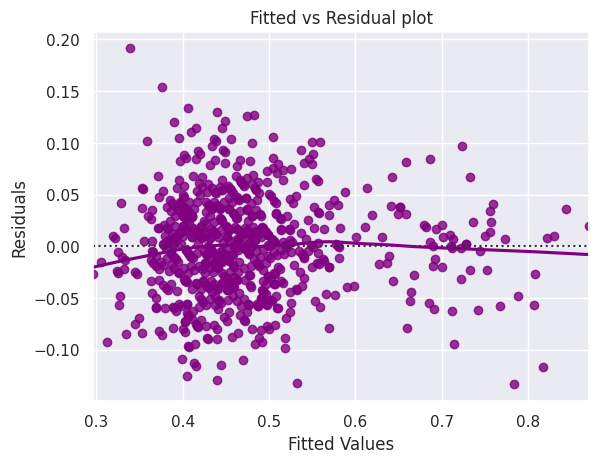

In [43]:
sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

- Since there is no pattern in the plot above. We can conclude he assumptions of linearity and independence are satisfied.

>> Test for Normality


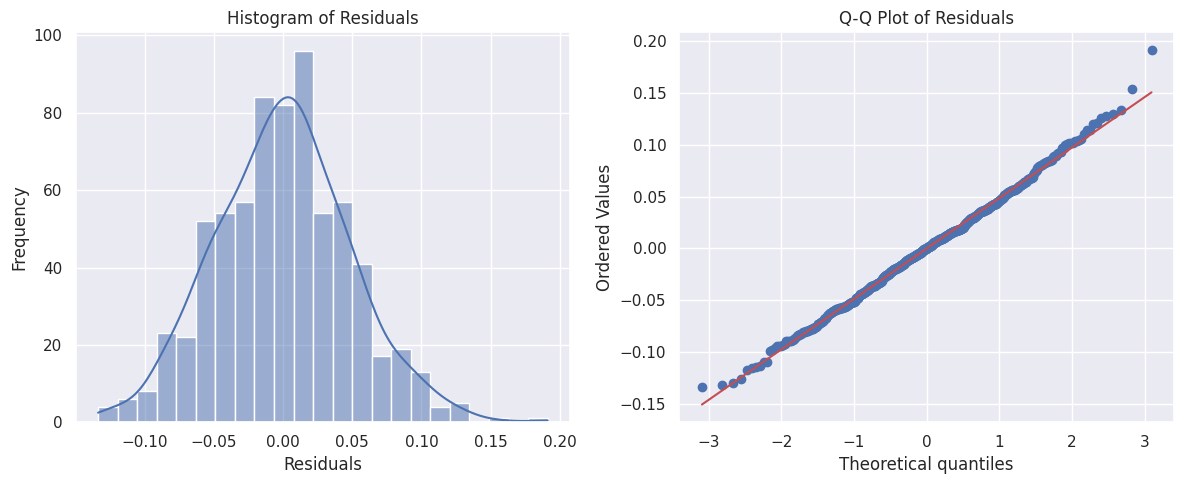

In [46]:
residuals = olsmod.resid

plt.figure(figsize=(12, 5))

# Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Q-Q plot of residuals
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=pylab)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [45]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9972310881741855), pvalue=np.float64(0.28468198171294534))

- Since p-value > 0.05, the residuals are normal as per the Shapiro-Wilk test.

>> Test for Homoscedasticity

Ho = residuals are homoscedastic

Ha = residuals are heteroscedastic

In [55]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value", "alternative"]
test = sms.het_goldfeldquandt(df_pred["Residuals"],X_train)
lzip(name, test)

/tmp/ipykernel_2239/1844839613.py:6: FutureWarning: het_goldfeldquandt currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a GoldfeldQuandtResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  test = sms.het_goldfeldquandt(df_pred["Residuals"],X_train)


[('F statistic', np.float64(1.1444079593563594)),
 ('p-value', np.float64(0.1108677095752728)),
 ('alternative', 'increasing')]

- Since the p_value > 0.05, we can conclude that the residuals are homoscedastic

> ### Linear Equation:

In [37]:
olsmod.params

,0
const,0.060157
visitors,0.129451
ad_impressions,0.000004
major_sports_event,-0.060326
views_trailer,0.002330
genre_Comedy,0.009352
genre_Drama,0.012625
genre_Horror,0.009862
genre_Others,0.006325
genre_Romance,0.000551


In [38]:
Equation = 'Viewership ='
print(Equation, end = ' ')
for i in range(len(X_train.columns)):
  if i == 0:
    print(olsmod.params[i],'+', end = ' ')
  elif i != len(X_train.columns) - 1:
    print(olsmod.params[i],'* (',X_train.columns[i],') +', end = ' ')
  else:
    print(olsmod.params[i],'* (',X_train.columns[i],')')

Viewership = 0.06015655174942062 + 0.12945057444234848 * ( visitors ) + 3.6231483229716364e-06 * ( ad_impressions ) + -0.060326091957429474 * ( major_sports_event ) + 0.0023296732638245048 * ( views_trailer ) + 0.009352182723248732 * ( genre_Comedy ) + 0.012625081979422761 * ( genre_Drama ) + 0.009862438834606024 * ( genre_Horror ) + 0.006325042184391205 * ( genre_Others ) + 0.0005509751584568227 * ( genre_Romance ) + 0.01314342655971494 * ( genre_Sci-Fi ) + 0.008707503270430461 * ( genre_Thriller ) + 0.03366163139753747 * ( dayofweek_Monday ) + 0.05788749657271269 * ( dayofweek_Saturday ) + 0.03632087548608468 * ( dayofweek_Sunday ) + 0.017289086216757864 * ( dayofweek_Thursday ) + 0.0228369184858207 * ( dayofweek_Tuesday ) + 0.04737607155228771 * ( dayofweek_Wednesday ) + 0.022602339842472913 * ( season_Spring ) + 0.044203446019333605 * ( season_Summer ) + 0.027161220661786695 * ( season_Winter )


/tmp/ipykernel_1435/2181517504.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsmod.params[i],'+', end = ' ')
/tmp/ipykernel_1435/2181517504.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsmod.params[i],'* (',X_train.columns[i],') +', end = ' ')
/tmp/ipykernel_1435/2181517504.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsmod.params[i],'* (',X_train.columns[i],')')
